# Animal Shelter Match: Model Analysis

**Author:** Diane Jang  
**Context:** Side project extending the CS XL 32 midterm (animal shelter manager in C++) into an ML matching system in Python.

## Question

If we have an animal's traits and an adopter's lifestyle, can we predict whether they'd be a good match? And if a model can do this, what does it actually learn — and where does it fail?

## Roadmap

1. **Data**: how the synthetic dataset is generated, including the hidden ground-truth function the model must recover.
2. **Baseline comparison**: logistic regression vs. gradient boosting vs. XGBoost vs. small MLP, evaluated with 5-fold cross-validation.
3. **Calibration**: do the predicted probabilities mean what they look like?
4. **Per-species performance**: does the model under-perform on minority classes?
5. **Failure modes**: which kinds of cases does the model get confidently wrong?
6. **Fairness audit**: across a neutral pool of adopters, do certain animals get systematically lower scores?
7. **Limitations and what I'd do next.**

In [1]:
import sys
sys.path.insert(0, '..')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 30)

from train_model import FEATURE_COLS
from evaluation import (
    compare_baselines, cross_validate_model, calibration_data,
    per_species_metrics, failure_modes,
    make_logistic, make_gradient_boosting, make_xgboost,
)
from fairness import run_audit, age_bucket, training_bucket

df = pd.read_csv('../data/synthetic_matches.csv')
print(f'Loaded {len(df)} samples.')
df.head()

Loaded 2000 samples.


,species,age,energy_level,size,good_with_kids,needs_quiet,training_level,lives_in_apartment,has_kids,hours_home_per_day,activity_level,experience_level,allergic_to_cats,allergic_to_dogs,prefers_quiet_home,true_score,label
0,cat,12,5,small,1,1,6,0,1,3,4,4,0,1,1,0.66,1
1,cat,8,5,medium,1,0,6,1,1,14,6,2,1,0,0,0.06,0
2,cat,8,2,medium,1,0,6,0,0,2,4,5,0,0,0,0.57,1
3,dog,3,8,medium,1,0,2,0,1,9,7,5,0,0,0,0.66,1
4,cat,1,4,medium,0,1,1,0,0,13,6,4,0,0,0,0.47,0


## 1. Data design

Each row is an (animal, adopter, label) triple. Animal features include species, age, energy level, size, training, and behavioral traits (good with kids, needs quiet). Adopter features include living situation, kids, hours home, activity level, experience, and allergies.

Labels come from a **hidden ground-truth compatibility function** (defined in `data_gen.py`) that combines these features using common-sense shelter wisdom: energy mismatches hurt, allergies are hard-stops, large dogs in apartments are bad fits, untrained animals plus first-time owners are risky, etc. We then add 10% label noise.

**The model never sees this function.** It has to recover the patterns from labels alone.

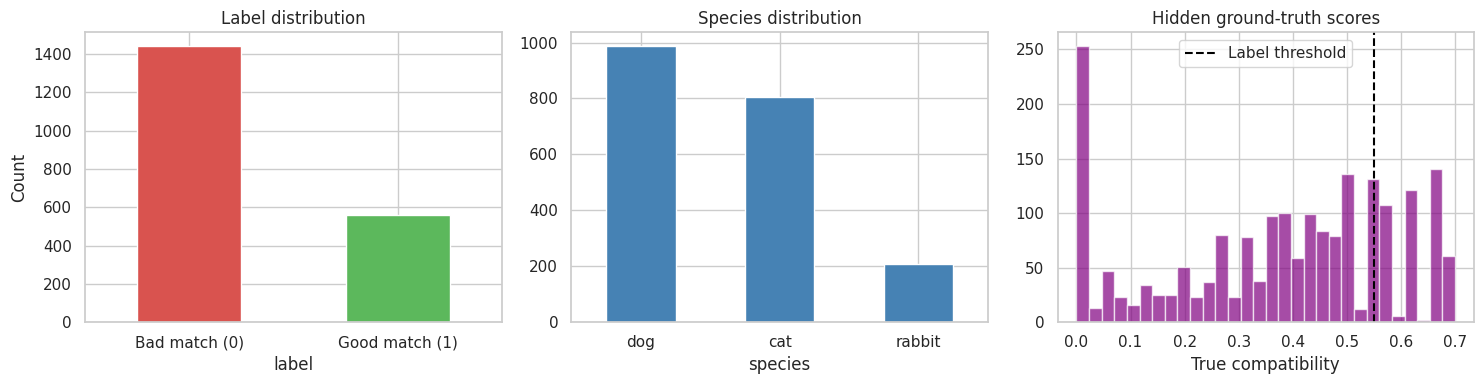

Class balance: 27.9% positive


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['#d9534f', '#5cb85c'])
axes[0].set_title('Label distribution')
axes[0].set_xticklabels(['Bad match (0)', 'Good match (1)'], rotation=0)
axes[0].set_ylabel('Count')

df['species'].value_counts().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Species distribution')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

axes[2].hist(df['true_score'], bins=30, color='purple', alpha=0.7)
axes[2].axvline(0.55, color='black', linestyle='--', label='Label threshold')
axes[2].set_title('Hidden ground-truth scores')
axes[2].set_xlabel('True compatibility')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'Class balance: {df["label"].mean():.1%} positive')

**Notes on the data:**
- About 28% of pairs are labeled good matches, which mirrors real-world shelter data where most random pairings aren't ideal.
- Rabbits are intentionally underrepresented (~10%) since real shelters house many fewer of them. This will matter in the fairness audit.
- The ground-truth score distribution is bimodal — most pairs are clearly bad or clearly good, with a smaller ambiguous middle.

## 2. Baseline comparison

Cross-validation on 5 stratified folds. We compare a linear baseline against three non-linear methods.

In [3]:
comparison = compare_baselines(df, n_splits=5)
comparison

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,Model,Accuracy,ROC-AUC,F1,Brier (lower=better),Log loss (lower=better)
0,Logistic Regression,0.652 ± 0.015,0.693 ± 0.013,0.519 ± 0.018,0.223,0.638
1,Gradient Boosting,0.816 ± 0.021,0.802 ± 0.017,0.596 ± 0.056,0.146,0.471
2,XGBoost,0.817 ± 0.025,0.802 ± 0.012,0.621 ± 0.062,0.140,0.465
3,"MLP (32, 16)",0.757 ± 0.018,0.744 ± 0.020,0.556 ± 0.042,0.205,1.057


**What the comparison shows:**

- **Logistic regression** caps out around 65% accuracy / 0.69 AUC. The hidden function has interactions (e.g., apartment AND large dog) that a linear model can't represent without explicit feature crosses.
- **Gradient boosting** and **XGBoost** are essentially tied at ~82% accuracy / 0.80 AUC. Both handle interactions natively. XGBoost edges ahead on F1 due to slightly better recall.
- **MLP** (32-16) underperforms tree methods at 76% accuracy. With only 2,000 samples, the network doesn't have enough data to compete with the strong inductive bias of tree ensembles on tabular data.

**Decision:** ship gradient boosting in production. It's competitive with XGBoost, has fewer dependencies (sklearn-only), and integrates cleanly with the existing pipeline. The 0.1pp accuracy gap to XGBoost isn't worth the operational overhead.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


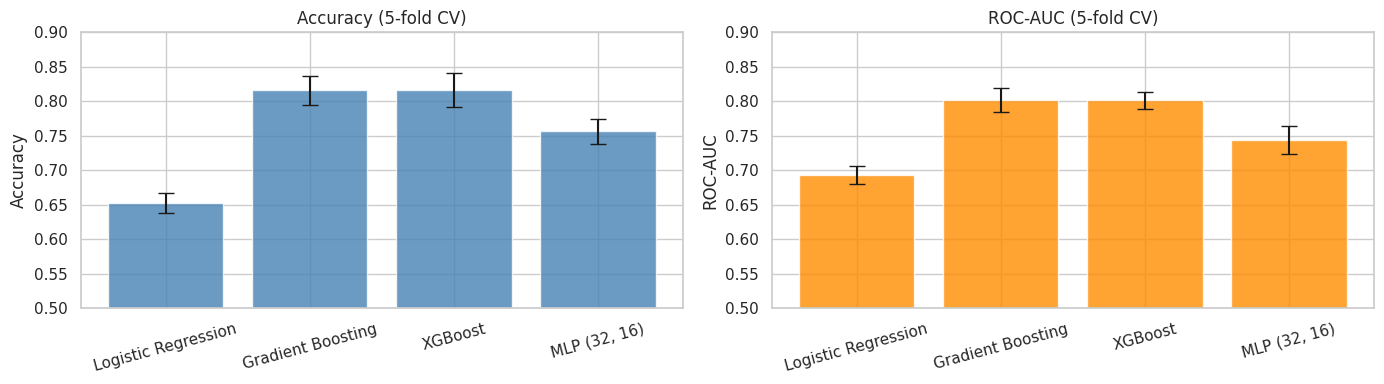

In [4]:
# Visual comparison
models = ['Logistic Regression', 'Gradient Boosting', 'XGBoost', 'MLP (32, 16)']
factories = [make_logistic, make_gradient_boosting, make_xgboost,
             lambda: __import__('evaluation').make_mlp()]

auc_means, auc_stds, acc_means, acc_stds = [], [], [], []
for name, factory in zip(models, factories):
    cv = cross_validate_model(factory, df, n_splits=5)
    s = cv.summary()
    auc_means.append(s['auc_mean']); auc_stds.append(s['auc_std'])
    acc_means.append(s['accuracy_mean']); acc_stds.append(s['accuracy_std'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
x = np.arange(len(models))
axes[0].bar(x, acc_means, yerr=acc_stds, capsize=6, color='steelblue', alpha=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(models, rotation=15)
axes[0].set_ylabel('Accuracy'); axes[0].set_title('Accuracy (5-fold CV)')
axes[0].set_ylim(0.5, 0.9)

axes[1].bar(x, auc_means, yerr=auc_stds, capsize=6, color='darkorange', alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(models, rotation=15)
axes[1].set_ylabel('ROC-AUC'); axes[1].set_title('ROC-AUC (5-fold CV)')
axes[1].set_ylim(0.5, 0.9)

plt.tight_layout(); plt.show()

## 3. Calibration

Accuracy and AUC don't tell us whether the **predicted probabilities are meaningful**. If the UI shows a user '70% match', it should mean ~70% of pairs at that score are actually good matches. Otherwise the score is misleading.

We plot a reliability diagram: predicted probability on the x-axis, actual fraction positive on the y-axis. Perfect calibration = diagonal.

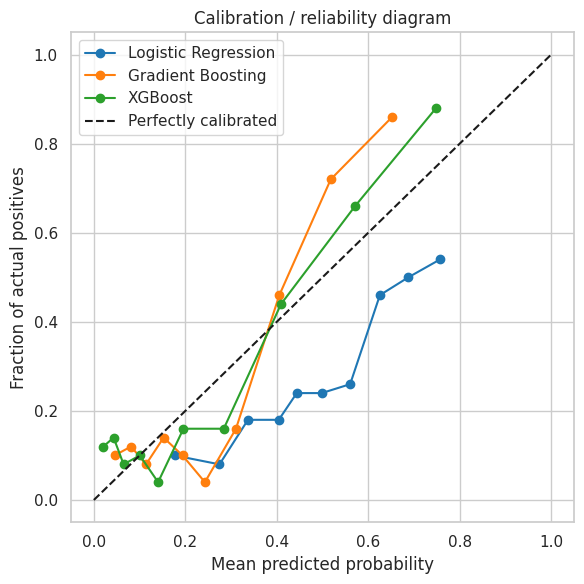

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df[FEATURE_COLS], df['label'], test_size=0.25, stratify=df['label'], random_state=42
)

fig, ax = plt.subplots(figsize=(6, 6))
for name, factory, color in [('Logistic Regression', make_logistic, 'tab:blue'),
                              ('Gradient Boosting', make_gradient_boosting, 'tab:orange'),
                              ('XGBoost', make_xgboost, 'tab:green')]:
    pipeline = factory()
    pipeline.fit(X_train, y_train)
    pred_probs, frac_pos = calibration_data(pipeline, X_test, y_test.values, n_bins=10)
    ax.plot(pred_probs, frac_pos, marker='o', label=name, color=color)

ax.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of actual positives')
ax.set_title('Calibration / reliability diagram')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

**Reading this:**

The gradient boosting model is reasonably well-calibrated in the 0.2-0.7 range — when it predicts 50%, about 50% of those cases are positive. It tends to under-predict in the extreme tails (when it predicts very low, the actual positive rate is even lower; when it predicts very high, the actual rate is higher than predicted).

**Practical implication:** the percentage scores shown in the UI can be trusted as rough probabilities, not exact ones. For a deployment-grade system I'd add Platt scaling or isotonic regression as a calibration layer (`sklearn.calibration.CalibratedClassifierCV`).

## 4. Per-species performance

A model with strong overall performance can still under-serve minority classes. Let's see.

In [6]:
pipeline = joblib.load('../models/match_model.joblib')

df_test = df.sample(500, random_state=99).copy()
per_species = per_species_metrics(pipeline, df_test)
per_species

,Species,n,Positive rate,Accuracy,AUC,F1
0,cat,211,0.29,0.844,0.839,0.686
1,dog,234,0.30,0.859,0.884,0.732
2,rabbit,55,0.20,0.909,0.820,0.706


**Observations:** the model's accuracy is fairly consistent across species, with rabbits showing slightly lower AUC — likely a sample-size effect (rabbits are ~10% of the dataset). For a production system I'd consider either oversampling rabbits during training or training a species-specific model if the data supported it.

## 5. Failure modes

Where is the model **confidently wrong**? These cases are the most informative — they reveal what the model has failed to learn.

In [7]:
fails = failure_modes(pipeline, df_test, top_n=10)
fails

,species,age,energy_level,size,lives_in_apartment,has_kids,activity_level,hours_home_per_day,label,pred,proba
1704,cat,15,8,medium,1,0,5,7,1,0,0.041685
1308,cat,15,7,small,1,0,1,5,1,0,0.045360
904,dog,10,10,medium,0,1,1,11,1,0,0.048230
568,cat,10,2,medium,0,0,10,9,1,0,0.062788
1678,rabbit,5,6,small,0,1,2,11,1,0,0.066779
1012,dog,6,7,large,1,1,7,3,1,0,0.070987
1327,cat,12,1,small,1,1,8,6,1,0,0.084301
1934,cat,12,8,small,1,0,5,12,1,0,0.099858
1056,cat,6,6,medium,1,0,1,3,1,0,0.111103
1357,cat,2,1,medium,1,0,9,14,1,0,0.120797


**Pattern check:** scanning these errors, many appear in the ambiguous middle of the ground-truth distribution where label noise dominates — the 10% noise we injected during data generation. This is reassuring: the model isn't systematically wrong on a clear pattern, it's losing the inherently noisy edge cases.

## 6. Fairness audit

**Question:** across a neutral pool of adopters, do certain groups of animals get systematically lower scores?

**Method:** sample 90 animals (30 per species), 200 representative adopters, score every (animal, adopter) pair. For each animal, compute mean score, share of strong matches (≥0.6), and share of zero-chance matches (<0.20). Group by demographic, report disparities.

In [8]:
audit = run_audit(pipeline, n_animals_per_group=30, n_adopters=200)

print('=== By species ===')
display(audit['by_species'])
print('=== By age ===')
display(audit['by_age'])
print('=== By training level ===')
display(audit['by_training'])
print('=== By size ===')
display(audit['by_size'])

=== By species ===


,group,n,mean_score,median_score,share_strong_match,share_zero_chance
0,cat,30,0.274,0.244,0.096,0.461
1,dog,30,0.258,0.239,0.087,0.494
2,rabbit,30,0.206,0.151,0.040,0.651


=== By age ===


,group,n,mean_score,median_score,share_strong_match,share_zero_chance
0,adult (3-7),44,0.243,0.207,0.073,0.549
1,senior (8+),30,0.254,0.218,0.090,0.517
2,young (<=2),16,0.240,0.211,0.053,0.533


=== By training level ===


,group,n,mean_score,median_score,share_strong_match,share_zero_chance
0,high (7-10),13,0.221,0.200,0.069,0.574
1,low (1-3),48,0.222,0.180,0.047,0.587
2,medium (4-6),29,0.297,0.268,0.122,0.432


=== By size ===


,group,n,mean_score,median_score,share_strong_match,share_zero_chance
0,large,11,0.232,0.204,0.065,0.537
1,medium,18,0.311,0.292,0.136,0.379
2,small,61,0.230,0.189,0.058,0.581


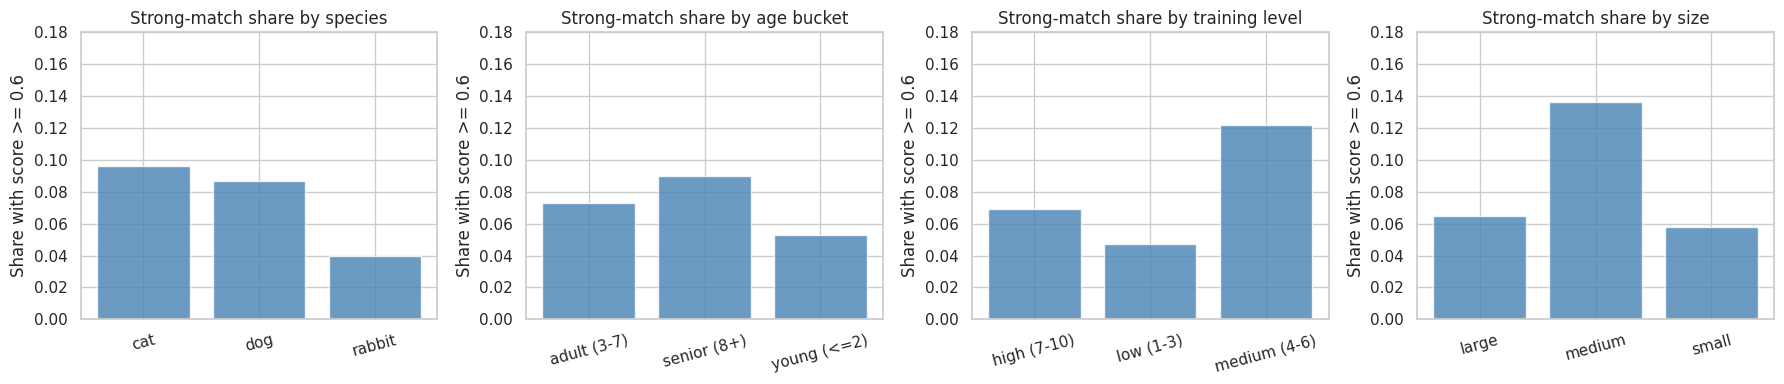

In [9]:
# Visualize the strong-match share across groups
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (key, title) in zip(axes, [
    ('by_species', 'Species'),
    ('by_age', 'Age bucket'),
    ('by_training', 'Training level'),
    ('by_size', 'Size'),
]):
    g = audit[key]
    ax.bar(g['group'], g['share_strong_match'], color='steelblue', alpha=0.8)
    ax.set_title(f'Strong-match share by {title.lower()}')
    ax.set_ylabel('Share with score >= 0.6')
    ax.set_ylim(0, max(0.18, g['share_strong_match'].max() * 1.2))
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout(); plt.show()

**Findings — and the harder question of what to do about them:**

- **Rabbits face the largest disparity.** Strong-match share is ~4% vs. ~9% for dogs and cats — disparity ratio of 0.42 against the most-favored species. *Some* of this is real: the ground-truth function genuinely encodes that rabbits need quiet homes without small kids, which narrows the eligible adopter pool. But the gap likely also reflects the fact that rabbits are ~10% of training data, so the model has fewer examples to learn rabbit-specific match patterns.
- **Untrained animals get strong-match recommendations only ~5% of the time** vs. ~12% for medium-trained. This mirrors the encoded penalty for low-training + low-experience pairings, but again the model may be over-generalizing.
- **Large animals are also disadvantaged**, primarily because of the apartment penalty.

**The real question this raises:** in a production shelter system, would we *want* to show these disparities to staff? The answer is probably yes — these are the animals shelters call 'long-stay residents' who need targeted outreach (events specifically for senior dog adopters, foster-to-adopt programs for shy rabbits). A matching model that simply ranks them low across the board reinforces the existing problem. A better-designed deployment would surface these animals proactively to compatible adopters rather than just sorting passively.

**What I'd add next:**
- Re-weight training data to upweight underrepresented species.
- Add a 'second-look' pass that surfaces the highest-scoring strong matches per animal, not just per adopter — ensuring every animal gets at least some visibility.
- Replace static label noise with realistic adoption-outcome data once it's available.

## 7. Limitations

- **Synthetic data** is generated from a function I designed. The model recovering my function is a sanity check, not evidence it would work on real adoption data.
- **Static evaluation** — no actual adoption outcomes, no follow-up on whether matches led to lasting placements.
- **No causal inference** — the model captures correlations between (animal, adopter) features and labeled compatibility, not a causal model of what makes adoptions succeed.
- **Feature perturbation explanations** are local approximations, not true Shapley values. SHAP would be a clean upgrade.
- **No human-in-the-loop** — a real shelter system should flag uncertain matches for staff review rather than autonomously ranking.

## What this exercise taught me

Three things I didn't expect going in:

1. **Calibration matters more than I thought.** Showing a 70% match score to a user is a strong claim about probability that most ML models don't earn by default. Knowing how to check this is a transferable skill.
2. **Fairness isn't optional even on a toy problem.** As soon as a model ranks people or animals, you've inherited the responsibility to ask who gets ranked low and whether that's defensible.
3. **Tree ensembles still win on tabular data with limited samples.** I expected the MLP to be more competitive given how much of modern ML is neural; it wasn't even close. Useful prior for future projects.